# Mood Space Interpolation Demo

This notebook demonstrates how to:
1. Train a Mood Space compression model on a small set of placeholder images
2. Generate interpolations across all of the images using the trained model
3. Visualize the interpolation results produced by blended cluster correspondences

The demo uses simple color swatches so you can quickly replace them with your own assets.

In [1]:
# Import required libraries
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from app import train_mood_space, perform_two_image_interpolation, perform_n_image_interpolation, perform_n_image_interpolation_per_cluster

## Prepare Images

Input Images (side by side):


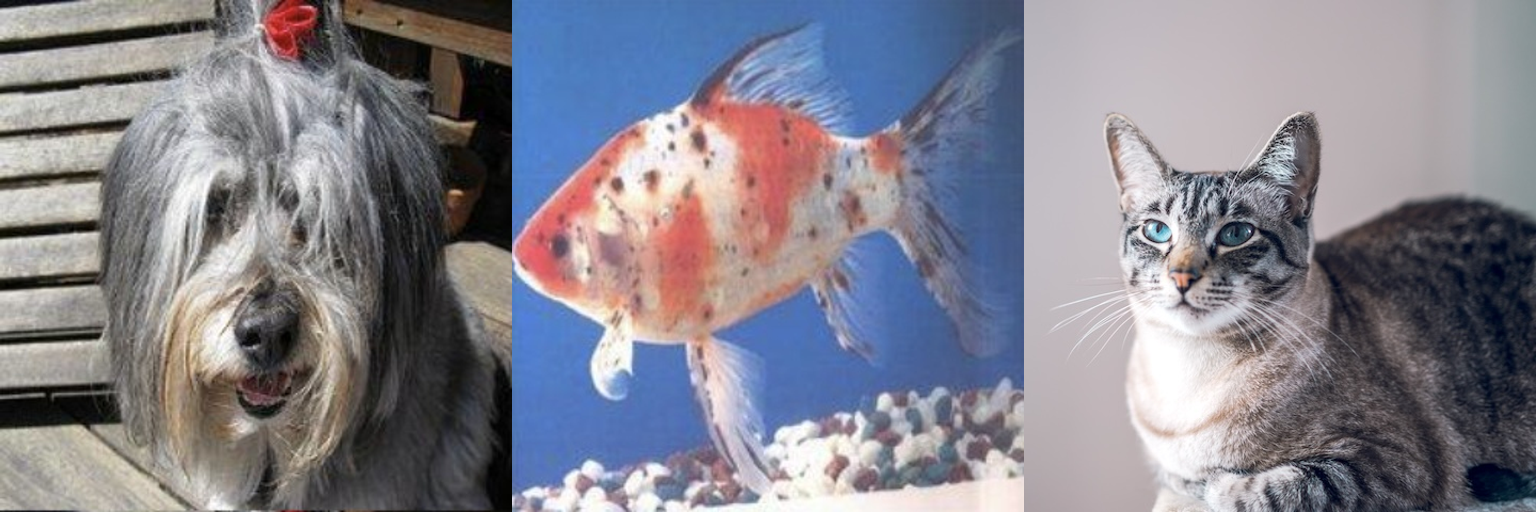

In [2]:
# Load images
image_paths = [
    "images/dog1.jpg",
    "images/fish.jpg",
    "images/cat.jpg"
]

image_size = (512, 512)
image_list = [Image.open(path).convert("RGB").resize(image_size) for path in image_paths]

print("Input Images (side by side):")
cols = len(image_list)
width, height = image_list[0].size
grid = Image.new("RGB", (cols * width, height))
for i, img in enumerate(image_list):
    grid.paste(img, (i * width, 0))
display(grid)

## Train Mood Space Model

In [3]:
# Train the Mood Space compression model
print("Training Mood Space model...")
model, trainer = train_mood_space(
    pil_images=image_list, 
    learning_rate=0.001, 
    training_steps=1000,
    mlp_width=512,
    mlp_layers=2
)
""
print("Training completed!")

Training Mood Space model...


Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Training: |          | 0/? [00:00<?, ?it/s]

Training completed!


## Generate Interpolation

Blend the inputs according to predefined weight vectors. Each vector is a linear combination over the three source images.

Generating interpolated images...


Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

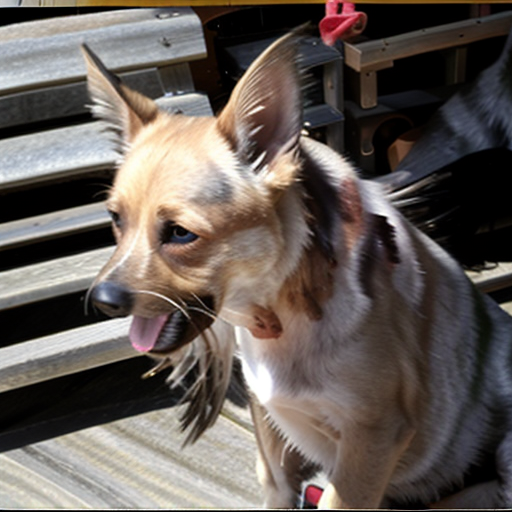

In [5]:
# Define interpolation weights for three-way blending per cluster
weight_schedule = [
    np.array([1.0, 0.0, 0.0], dtype=np.float32),
    np.array([0.0, 1.0, 0.0], dtype=np.float32),
    np.array([0.0, 0.0, 1.0], dtype=np.float32),
    np.array([0.5, 0.5, 0.0], dtype=np.float32),
    np.array([0.0, 0.5, 0.5], dtype=np.float32),
]

print("Generating interpolated images...")
interpolated_images = perform_n_image_interpolation_per_cluster(
    image_list=image_list, 
    base_image_idx=0,
    model=model, 
    interpolation_weights=weight_schedule,
    n_clusters=5, 
    match_method='hungarian',
    use_dino_matching=True
)

display(interpolated_images[0])